In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Python libraries loaded successfully")

Python libraries loaded successfully


In [2]:
orders = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
customers = pd.read_csv("customers.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
hubs = pd.read_csv("hubs.csv")
incidents = pd.read_csv("incidents.csv")
complaints = pd.read_csv("complaints.csv")
app_events = pd.read_csv("app_events.csv")

print("All CSV files loaded successfully")

All CSV files loaded successfully


In [3]:
row_counts = pd.DataFrame({
    "Dataset": ["orders", "deliveries", "customers", "drivers", "vehicles", "hubs", "incidents", "complaints", "app_events"],
    "Rows": [
        len(orders), len(deliveries), len(customers), len(drivers), len(vehicles),
        len(hubs), len(incidents), len(complaints), len(app_events)
    ]
})

row_counts

,Dataset,Rows
0,orders,1250
1,deliveries,950
2,customers,650
3,drivers,170
4,vehicles,120
5,hubs,8
6,incidents,280
7,complaints,320
8,app_events,640


In [4]:
# Clean zone names
def clean_zone(series):
    return series.str.strip().str.title()

orders['pickup_zone'] = clean_zone(orders['pickup_zone'])
orders['dropoff_zone'] = clean_zone(orders['dropoff_zone'])
customers['home_zone'] = clean_zone(customers['home_zone'])
drivers['base_zone'] = clean_zone(drivers['base_zone'])
vehicles['assigned_zone'] = clean_zone(vehicles['assigned_zone'])
app_events['zone_context'] = clean_zone(app_events['zone_context'])

print("Zone names cleaned successfully")

Zone names cleaned successfully


In [5]:
# Convert datetime columns
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'], errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')

# Create new features
deliveries['delivery_duration_hrs'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

deliveries['is_delayed'] = (deliveries['delivery_status'] == 'Delayed').astype(int)
deliveries['is_failed'] = (deliveries['delivery_status'] == 'Failed').astype(int)
deliveries['is_problem'] = deliveries['is_delayed'] + deliveries['is_failed']

deliveries['cost_per_km'] = deliveries['fuel_or_charge_cost'] / deliveries['route_distance_km']

print("Feature engineering completed")

Feature engineering completed


In [6]:
missing_values = deliveries.isnull().sum().sort_values(ascending=False)

missing_values

,0
delivery_duration_hrs,19
delivery_completed_at,19
customer_rating_post_delivery,14
delivery_id,0
order_id,0
driver_id,0
dispatch_time,0
delivery_status,0
hub_id,0
vehicle_id,0


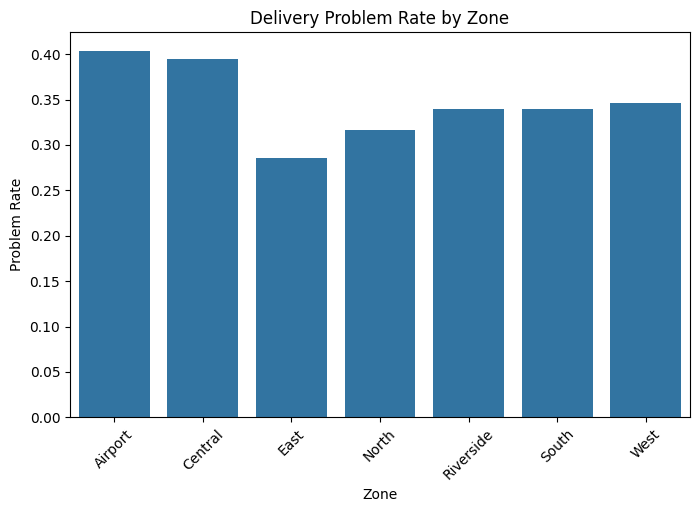

In [7]:
import seaborn as sns

hub_data = deliveries.merge(hubs, on='hub_id')

problem_by_hub = hub_data.groupby('zone')['is_problem'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=problem_by_hub, x='zone', y='is_problem')

plt.title("Delivery Problem Rate by Zone")
plt.xlabel("Zone")
plt.ylabel("Problem Rate")

plt.xticks(rotation=45)
plt.show()

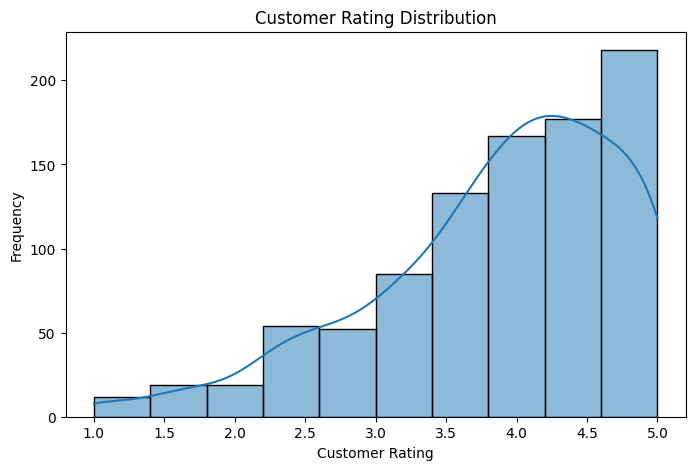

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(deliveries['customer_rating_post_delivery'], bins=10, kde=True)

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Frequency")

plt.show()

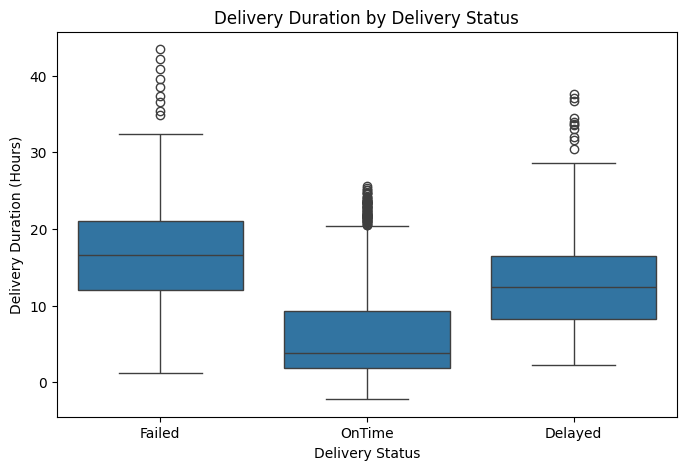

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x=deliveries['delivery_status'], y=deliveries['delivery_duration_hrs'])

plt.title("Delivery Duration by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Delivery Duration (Hours)")

plt.show()

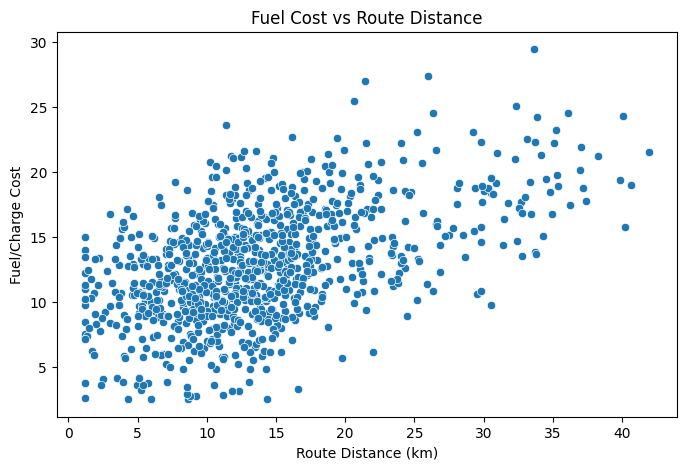

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=deliveries['route_distance_km'], y=deliveries['fuel_or_charge_cost'])

plt.title("Fuel Cost vs Route Distance")
plt.xlabel("Route Distance (km)")
plt.ylabel("Fuel/Charge Cost")

plt.show()

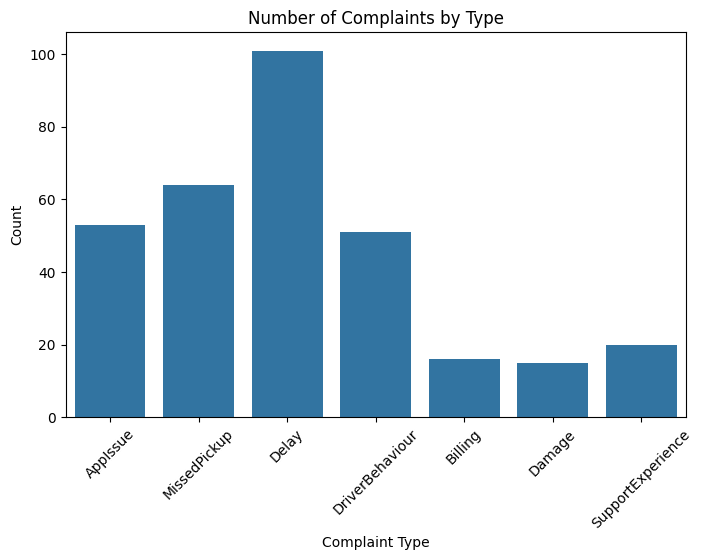

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=complaints, x='complaint_type')

plt.title("Number of Complaints by Type")
plt.xlabel("Complaint Type")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()